# Аггрегация данных #

Пришло время собрать всю информацию воендино и провесети анализ

In [ ]:
! git clone https://github.com/mnedo/SMADIMO_GP2/

## Загрзка собранных раннее данных ##

In [ ]:
import pandas as pd

In [ ]:
cities = pd.read_excel('/content/SMADIMO_GP2/Data/cities.xlsx')
cities.head(3)

,Unnamed: 0,Город,Регион,Федеральный округ,Население,Наличие аэропорта
0,1,Абакан,Хакасия,Сибирский,184284,True
1,26,Анадырь,Чукотский АО,Дальневосточный,13224,True
2,27,Анапа,Краснодарский край,Южный,84804,True


In [ ]:
hotels = pd.read_excel('/content/SMADIMO_GP2/Data/hotels.xlsx')
hotels.head(3)

,city_name,hotel_name,reviews_count,rating_value,price_per_night,latitude,longitude
0,Абакан,Гостиница Хакасия,98.0,8.2,5540,53.722572,91.44298
1,Абакан,AZIMUT Отель Абакан 3*,16.0,9.3,4828,53.721160,91.43992
2,Абакан,Уютная Квартира в Центре Города,19.0,9.7,2666,53.719868,91.42204


In [ ]:
sightseens = pd.read_csv('/content/SMADIMO_GP2/Data/sightseens.csv')
sightseens.head(3)

,city,rubric,name,lat,lon,rating,review_count
0,Абакан,Рестораны,"STIX, бельгийский ресторан",53.721736,91.444138,4.7,648
1,Абакан,Рестораны,"Мажор, караоке-бар",53.725752,91.456086,4.7,307
2,Абакан,Рестораны,"Мадрид, кафе",53.727392,91.437827,4.6,300


In [ ]:
flights = pd.read_excel('/content/SMADIMO_GP2/Data/flights.xlsx')
flights.head(3)

,from_city,from_code,to_city,to_code,price,duration
0,Абакан,ABA,Анадырь,DYR,39655,2850
1,Абакан,ABA,Барнаул,BAX,11714,175
2,Абакан,ABA,Владивосток,VVO,20241,2015


## Стоимость путшествия ##

In [ ]:
flights = flights.merge(cities[['Город', 'Население']].rename(columns={'Город': 'from_city'}), on='from_city', how='left')
flights = flights.rename(columns={'Население': 'from_population'})

In [ ]:
# to-delete
flights = flights[flights['from_population'].notna()]
hotels = hotels[hotels['rating_value'].notna()]

In [ ]:
gr = flights.groupby(by=['to_city']).agg({'from_population': 'sum'}).rename(columns={'from_population': 'total_population'}).reset_index()
flights = flights.merge(gr, on='to_city')
flights.head(2)

,from_city,from_code,to_city,to_code,price,duration,from_population,total_population
0,Абакан,ABA,Анадырь,DYR,39655,2850,184284,9243775
1,Абакан,ABA,Барнаул,BAX,11714,175,184284,26449801


In [ ]:
flights['from_city_importance'] = flights['from_population']/flights['total_population']
flights['mult_ptice'] = flights['from_city_importance'] * flights['price']


In [ ]:
flights_res = flights.groupby(by=['to_city']).agg({'mult_ptice': 'sum'}).reset_index().rename(columns={'to_city': 'city_name', 'mult_ptice': 'flight_price_weighted'})
flights_res.head(2)

,city_name,flight_price_weighted
0,Абакан,15512.577006
1,Анадырь,32702.881648


In [ ]:
rng, Imin = flights_res['flight_price_weighted'].max() - flights_res['flight_price_weighted'].min(), flights_res['flight_price_weighted'].min()
flights_res['flight_price_weighted'] = (flights_res['flight_price_weighted']-Imin)/rng

## Привлекательность местоположение

Для каждого города и типа достопримечательности у нас есть разное количество оценок. И конечно количество оценок должно иметь вес при учете средней оценки - рейтинга.

Введем коэффициент важности оценки: Доля от максимального количество оценок в city+rubric

In [ ]:
gr = sightseens.groupby(by=['city', 'rubric']).agg({'review_count': 'max'}).rename(columns={'review_count': 'max_count'}).reset_index()
sightseens = sightseens.merge(gr, on=['city', 'rubric'])

In [ ]:
sightseens['review_importance'] = sightseens['review_count']/sightseens['max_count']
sightseens['I'] = sightseens['rating']*sightseens['review_importance'] # total importance
rng, Imin = sightseens['I'].max() - sightseens['I'].min(), sightseens['I'].min()
sightseens['I'] = (sightseens['I']-Imin)/rng

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
help(plt.hist)

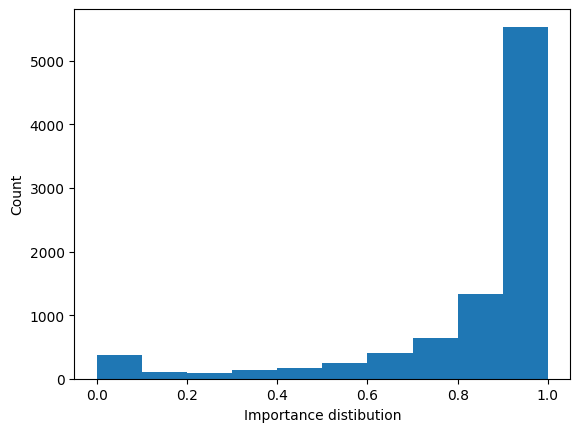

In [228]:
plt.hist(-sightseens['I']+1, range=(0, 1))
plt.xlabel('Importance distibution')
plt.ylabel('Count')
plt.show()

In [ ]:
calcdf = hotels[['city_name', 'hotel_name', 'latitude',	'longitude']].rename(columns={'city_name': 'city'}).merge(sightseens[['city', 'I', 'lat', 'lon', 'rubric']], on='city')
calcdf.head(3)

,city,hotel_name,latitude,longitude,I,lat,lon,rubric
0,Абакан,Гостиница Хакасия,53.722572,91.44298,0.560884,53.721736,91.444138,Рестораны
1,Абакан,Гостиница Хакасия,53.722572,91.44298,0.265727,53.725752,91.456086,Рестораны
2,Абакан,Гостиница Хакасия,53.722572,91.44298,0.254144,53.727392,91.437827,Рестораны


Мы будем использовать библиотеку geopy как доп. инструмент для расчета расстояния по широте и долготое: https://pypi.org/project/geopy/

In [ ]:
pip install geopy

In [ ]:
from geopy.distance import geodesic as dist

In [ ]:
calcdf = calcdf.dropna()

In [ ]:
calcdf['slagaemoe'] = calcdf.apply(lambda row: dist((row['latitude'], row['longitude']), (row['lat'], row['lon'])).km * row['I'], axis=1)
calcdf.head(3)

,city,hotel_name,latitude,longitude,I,lat,lon,rubric,slagaemoe
0,Абакан,Гостиница Хакасия,53.722572,91.44298,0.560884,53.721736,91.444138,Рестораны,0.067542
1,Абакан,Гостиница Хакасия,53.722572,91.44298,0.265727,53.725752,91.456086,Рестораны,0.248378
2,Абакан,Гостиница Хакасия,53.722572,91.44298,0.254144,53.727392,91.437827,Рестораны,0.161434


In [ ]:
gr = calcdf.groupby(by=['hotel_name', 'rubric']).agg({'slagaemoe': 'sum'}).rename(columns={'slagaemoe': 'weigthed_sum_atnes'}).reset_index()
rng, Imin = gr['weigthed_sum_atnes'].max() - gr['weigthed_sum_atnes'].min(), gr['weigthed_sum_atnes'].min()
gr['weigthed_sum_atnes'] =  1- (gr['weigthed_sum_atnes']-Imin)/rng

Посмотрим на распределение оценок по типам объектов привлечения
sources: https://github.com/mnedo/ML-intro_hse_2025/blob/main/hw_03_visualisation.ipynb (домашка ИАД)

In [ ]:
import seaborn as sns

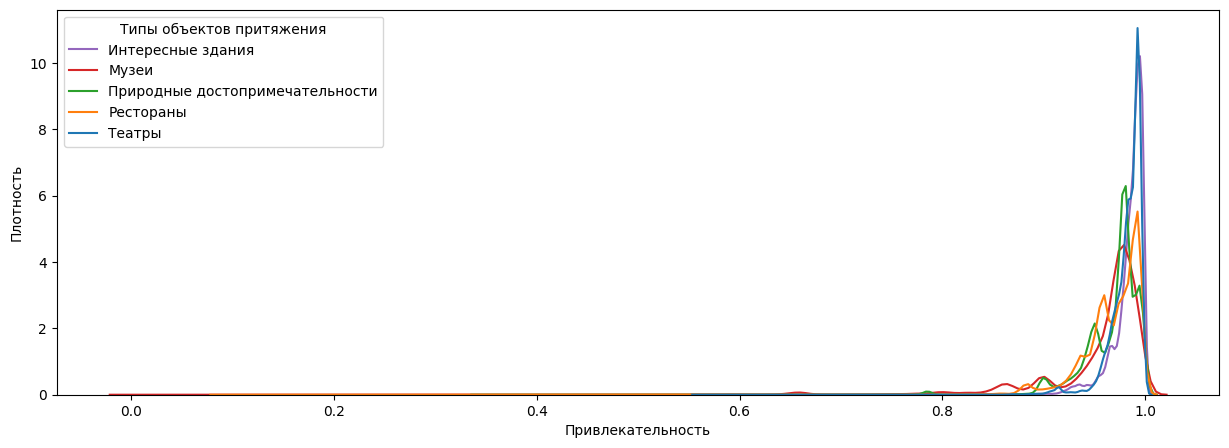

In [ ]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=gr, x='weigthed_sum_atnes', hue='rubric')
plt.xlabel('Привлекательность')
plt.ylabel('Плотность')
plt.legend(title='Типы объектов притяжения', loc='upper left', labels=gr['rubric'].unique())
plt.show()

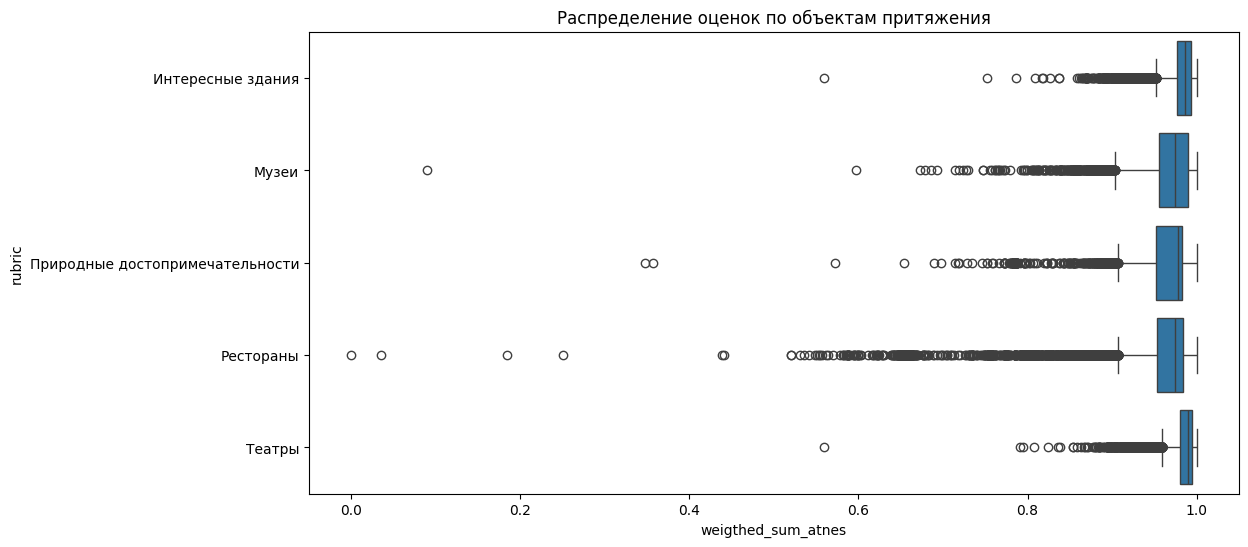

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='weigthed_sum_atnes', y='rubric', data=gr)
plt.title('Распределение оценок по объектам притяжения')
plt.show()

## Обогощение отелей ##

In [ ]:
pvt = gr.pivot_table(index='hotel_name', columns='rubric', values='weigthed_sum_atnes').reset_index()
hotels_w = hotels[['city_name',	'hotel_name',	'reviews_count',	'rating_value',	'price_per_night']].merge(pvt, on='hotel_name', how='left')

In [ ]:
hotels_w = hotels_w.merge(flights_res, on='city_name', how='left')
hotels_w.head(3)

,city_name,hotel_name,reviews_count,rating_value,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted
0,Абакан,Гостиница Хакасия,98.0,8.2,5540,0.907553,0.929898,0.960007,0.973692,0.943757,0.297134
1,Абакан,AZIMUT Отель Абакан 3*,16.0,9.3,4828,0.907362,0.929768,0.960009,0.973278,0.943646,0.297134
2,Абакан,Уютная Квартира в Центре Города,19.0,9.7,2666,0.905872,0.928566,0.959723,0.970951,0.941976,0.297134


In [ ]:
# SAVE
# to-delete

hotels_w.to_excel("hotels_w.xlsx", index=False)
from google.colab import files
hotels_w.download("hotels_w.xlsx")

AttributeError: 'DataFrame' object has no attribute 'download'

In [ ]:
# UNSAVE
# to-delete

hotels_w = pd.read_excel('hotels_w.xlsx')
hotels_w = hotels_w[hotels_w['rating_weighted'] > 0]
hotels_w = hotels_w[hotels_w['flight_price_weighted'] > 0]

## Анализ и репрезентация полученных результатов ##

Стоит обработать оценку отеля: опять будем учитывать максимальную оценку в городе и отнормируемм

In [ ]:
hotels_w = hotels_w[hotels_w['rating_value'].notna()]

In [ ]:
gr = hotels_w.groupby(by=['city_name']).agg({'reviews_count': 'max'}).rename(columns={'reviews_count': 'max_count'}).reset_index()
hotels_w = hotels_w.merge(gr, on=['city_name'])
hotels_w['reviews_importance'] = hotels_w['reviews_count']/hotels_w['max_count']
hotels_w['rating_weighted'] = hotels_w['rating_value']*hotels_w['reviews_importance']
rng, Imin = hotels_w['rating_weighted'].max() - hotels_w['rating_weighted'].min(), hotels_w['rating_weighted'].min()
hotels_w['rating_weighted'] = (hotels_w['rating_weighted']-Imin)/rng
hotels_w.drop(columns=['reviews_importance', 'reviews_count', 'rating_value', 'max_count'], inplace=True)
hotels_w.head(3)

Наш статистический таргет - оценка отеля. Высокая оценка = высокий поток довольных клиентов

In [ ]:
import numpy as np

In [ ]:
hotels_w = hotels_w.rename(columns={'rating_weighted': 'target'})

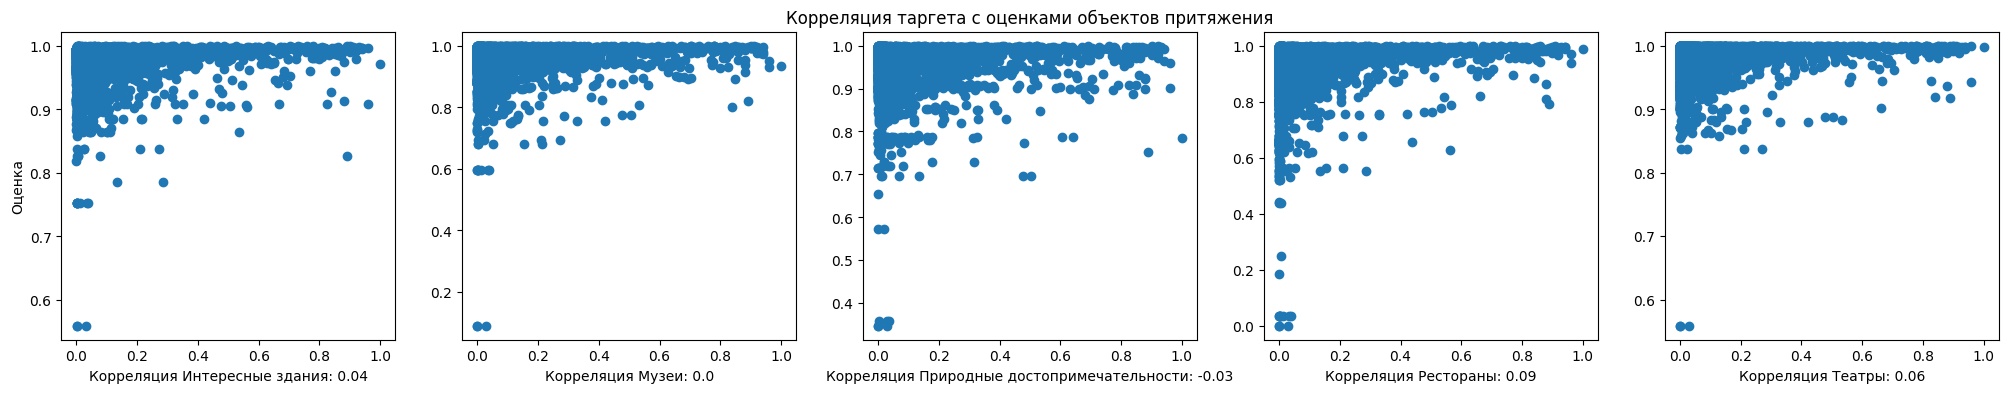

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
cols = ['Интересные здания',	'Музеи',	'Природные достопримечательности',	'Рестораны',	'Театры']
for i in range(5):
  col = cols[i]
  axes[i].scatter(hotels_w['target'], hotels_w[col])
  axes[i].set_xlabel(f'Корреляция {col}: {np.round(hotels_w["target"].corr(hotels_w[col]), 2)}')
axes[2].set_title('Корреляция таргета с оценками объектов притяжения')
axes[0].set_ylabel('Оценка')
fig.show()

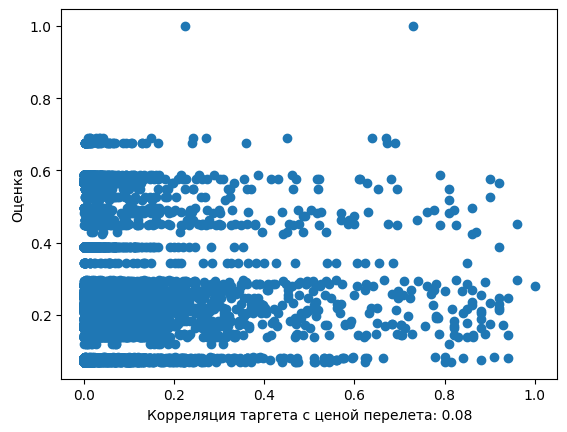

In [ ]:
plt.scatter(hotels_w['target'], hotels_w['flight_price_weighted'])
plt.xlabel(f'Корреляция таргета с ценой перелета: {np.round(hotels_w["target"].corr(hotels_w['flight_price_weighted']), 2)}')
plt.ylabel('Оценка')
plt.show()

In [226]:
list(hotels_w.columns)

['city_name',
 'hotel_name',
 'price_per_night',
 'Интересные здания',
 'Музеи',
 'Природные достопримечательности',
 'Рестораны',
 'Театры',
 'flight_price_weighted',
 'target']

<Axes: >

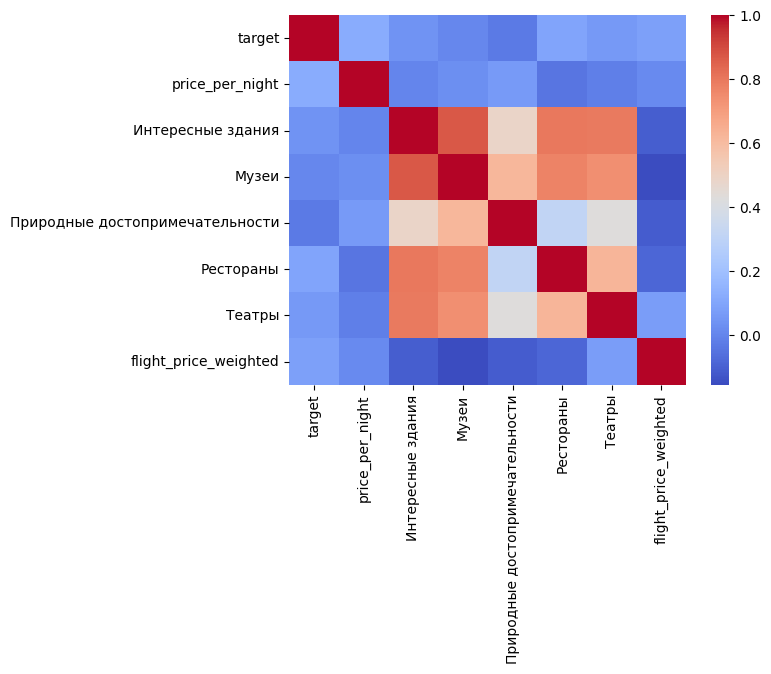

In [227]:
# to-delete
sns.heatmap(hotels_w[['target', 'city_name',
 'hotel_name',
 'price_per_night',
 'Интересные здания',
 'Музеи',
 'Природные достопримечательности',
 'Рестораны',
 'Театры',
 'flight_price_weighted']].corr(numeric_only=True), cmap='coolwarm')

In [ ]:
Выбор топ-5 городов с лучшими параметрами: стоимость билета (приоритет 2), средние оценки взевеш. театров (приоритет 1) и ресторанов (приоритет 3) + вот сюда можно folium (картинка ниже)

In [ ]:
Определение конкретного метоположение (средние lat и lon) - это я могу сделать

In [ ]:
Отображение на карте выбранных мест (топ-5)

In [ ]:
Рекомендации по концепции анализ топ-20